## Preprocess the Data for Dataset for YOLO Model

This is divided into 4 Chapters
- Chapter 1: transform a Radargramm into a image for a YOLO model
- Chapter 2: Create multiple images out of Our given Data
- Chapter 3: Normalize the Series of Images
- Chapter 4: Annotating/Labeling the Data

### Chapter 1: transform a Radargramm into a image for a YOLO model
trying to convert a Radargramm to an Image. **Pipeline/Datatoolkit** can be used to load the data and create a DataFrame.

In [1]:
#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

from Pipeline.Datatoolkit import DatatoolKit

dk1 = DatatoolKit(TEST_FILE_DIR,"UG3DQUERUNTERZUG.SGY")
dk2 = DatatoolKit(TEST_FILE_DIR,"EG-3D QUER001.SGY")


file1 = dk1.LoadSGY()
file2 = dk2.LoadSGY()


Next step is to create the Dataframes



In [2]:
df1 = dk1.create_df(file1)
df2 = dk2.create_df(file2)

#### Inline Plot

This is the same plot as shown in the notebook **Analyzing the Data**. It displays all crosslines for a single inline. In other words, it represents one slice through the inline.

**please note that it is only one inline**

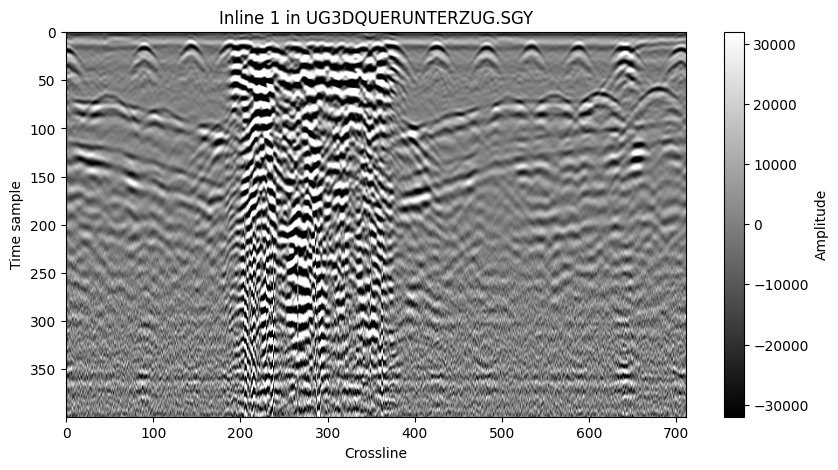

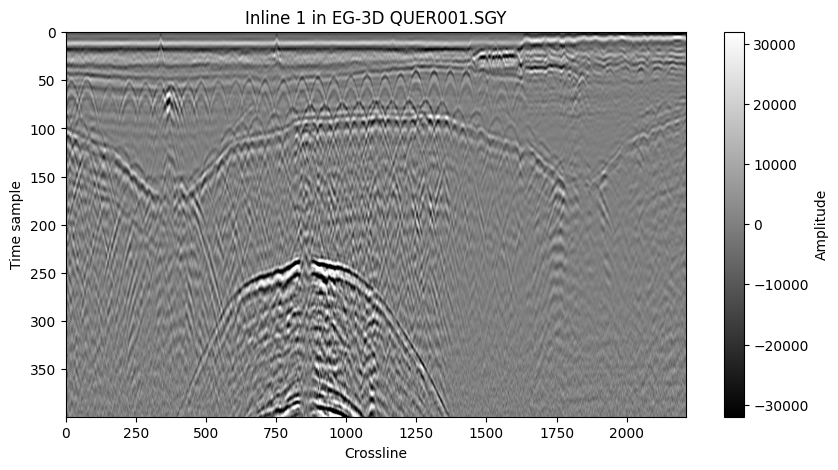

In [3]:
#function to plot crosslines on the x-axis and on the y-Axis the time samples
dk1.plot_inline_cut_raw(df1, 1)
dk2.plot_inline_cut_raw(df2, 1)

#### Crossline Plot

This is the same plot as in the notebook **Analyzing the Data**. It plots all inlines for a single crossline. This is again one slice a cut through the crosslines.

**please Note that it is only one Crossline**

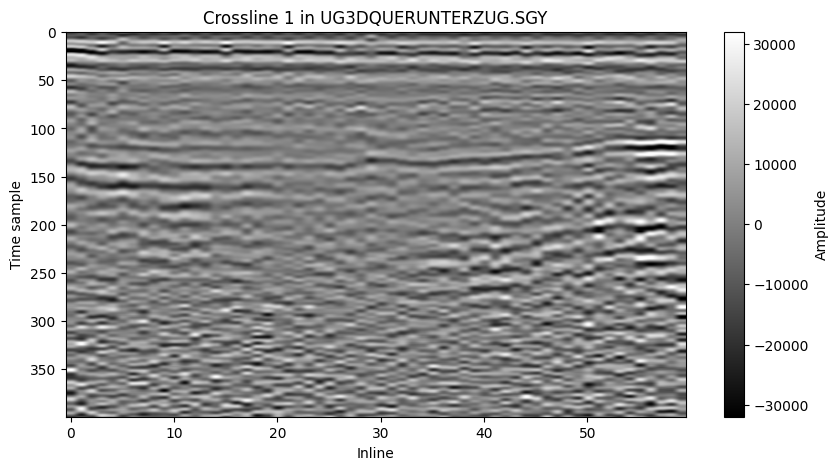

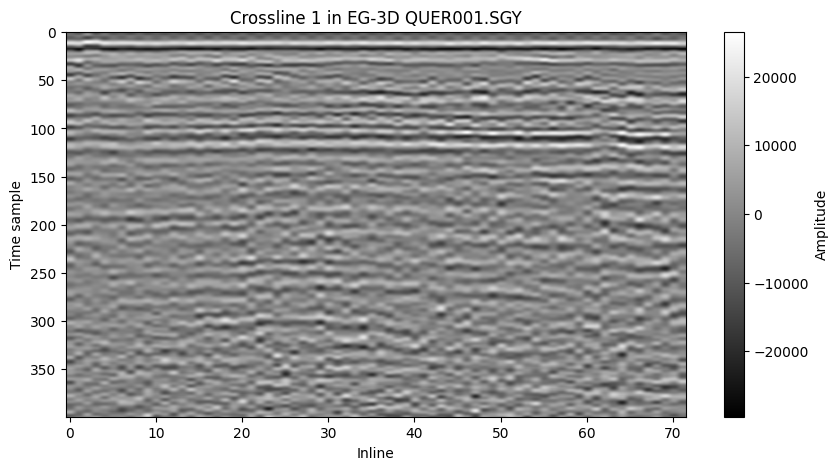

In [4]:
dk1.plot_crossline_cut_raw(df1, 1)
dk2.plot_crossline_cut_raw(df2, 1)

#### Time slice Plot

This is the same plot as in the notebook **Analyzing the Data**. It shows the complete grid from a top-down view. This represents a slice through the time axis a cut at a single point in time.

**Please Note that it is only one timeslice**

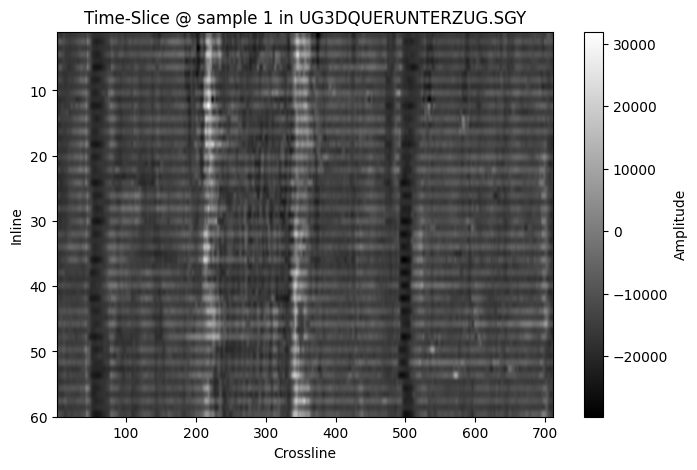

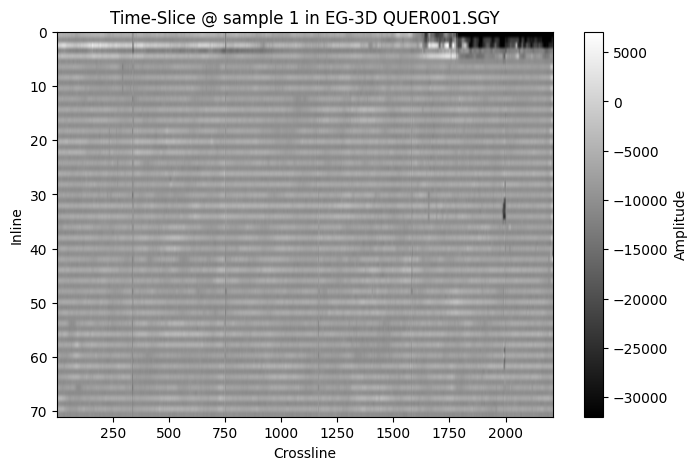

In [5]:
dk1.plot_timeslice_cut_raw(df1, 1)
dk2.plot_timeslice_cut_raw(df2 ,1)

For the further steps in **Chapter 1**, the focus is on the inline plots because they provide much higher spatial density. A second reason is that the analysis strategy is designed to prioritize inline sections because of the hyperbolas.
Below is a table showing the corresponding density.

In [6]:
import pandas as pd
# here we compare de density from Inline and crossline Plots by simple plot the inline X Crossline and Crossline X inline
inlinenr = 1
crosslinenr = 1

#Inline cut density
sub_file1_in = df1[df1["inline"] == inlinenr].sort_values("crossline")
sub_file2_in = df2[df2["inline"] == inlinenr].sort_values("crossline")

#crossline cut density
sub_file1_cr = df1[df1["crossline"] == crosslinenr].sort_values("inline")
sub_file2_cr = df2[df2["crossline"] == crosslinenr].sort_values("inline")



d = {"Datasource": ["file1", "file2", "file1", "file2"], 
     "plottype": ["inline cut", "inline cut", "crossline cut", "crossline cut"], 
     "Spherenr": [inlinenr, inlinenr, crosslinenr, crosslinenr],
     "traces for cut": [len(sub_file1_in), len(sub_file2_in), len(sub_file1_cr), len(sub_file2_cr)]}

df_density = pd.DataFrame(d)

df_density



,Datasource,plottype,Spherenr,traces for cut
0,file1,inline cut,1,711
1,file2,inline cut,1,2211
2,file1,crossline cut,1,60
3,file2,crossline cut,1,72


### Chapter 2: Create multiple images out of Our given Data

The Code for that ist pretty straightforward. Because it is basically a plot without the axis description and titles so the full Plot is the radargramm.

First it is done on one inline cut.

In [7]:

import numpy as np
import matplotlib.pyplot as plt
inline_nr = 1
sub = df1[df1["inline"] == inline_nr].sort_values("crossline")
radar_img = np.vstack(sub["Amplitude"].values).T  # (samples x traces)
plt.imsave("inline_036.png", radar_img, cmap="gray")
plt.close()



Next step is to implement a function to create images for a whole Dataset with options to chosse between inline, crossline and time slice.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import segyio

def create_train_images(df, file, inline:bool = False, crossline:bool = False, timeslice:bool= False):
    
    outdir = PICTURES_FOR_ANNOTATION
    filename = df["filename"].iloc[0]

    if inline:
        inlines = sorted(df["inline"].unique())
        for inline_nr in inlines:
            sub = df[df["inline"] == inline_nr].sort_values("crossline")
            img = np.vstack(sub["Amplitude"].values).T
            out_path = os.path.join(outdir, f"{filename}_inline_{inline_nr}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {inline_nr} images to {out_path}")

    if crossline:
        crosslines = sorted(df["crossline"].unique())
        for crossline_nr in crosslines:
            sub = df[df["crossline"] == crossline_nr].sort_values("inline")
            img = np.vstack(sub["Amplitude"].values).T
            out_path = os.path.join(outdir, f"{filename}_crossline_{crossline_nr}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {crossline_nr} images to {out_path}")

    if timeslice:

        bin_header = dict(file.bin)
        bin_header_dict = dict(bin_header)
        n_samples = int(bin_header_dict[segyio.BinField.Samples])

        inlines = np.sort(df["inline"].unique())
        crosslines = np.sort(df["crossline"].unique())
        

        il_map = {v:i for i,v in enumerate(inlines)}
        cl_map = {v:i for i,v in enumerate(crosslines)}

        for sample_index in range(n_samples):
            mat = np.full((len(inlines), len(crosslines)), np.nan)

            for _,row in df.iterrows():
                i = il_map[row["inline"]]
                j = cl_map[row["crossline"]]
                mat[i, j] = row["Amplitude"][sample_index]
        
            img = np.nan_to_num(mat)
            out_path=os.path.join(outdir, f"{filename}_timeslice_{sample_index}.png")
            plt.imsave(out_path, img, cmap="grey")
        
        print(f"saved {sample_index} images to {out_path}")






This function can now be used for creating a complete daataset for a YOLO Model for annotating.

- Here the inline_cuts are taken as images.

In [10]:
create_train_images(df1, file1, inline=True)

saved 60 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Data_for_Models\Pictures\UG3DQUERUNTERZUG.SGY_inline_60.png


In [11]:
create_train_images(df2, file2, inline=True)

saved 71 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Data_for_Models\Pictures\EG-3D QUER001.SGY_inline_71.png


### Chapter 3: Normalize the Series of Images

For ML workflows, it is best practice to normalize the data so that all values are on the same scale. This is where YOLO becomes useful, as it performs this normalization automatically during the training process. More details on how YOLO handles normalization and which methods are used can be found in the documentation of this work.

### Chapter 4: Annotating/Labeling the Data

Annotating the images is necessary to mark the regions of interest and assign labels to them. For this task, Roboflow is used, which also automatically creates a train/validation/test split.
https://roboflow.com/

### Chapter 5: Implementation in Pipeline

From the previous chapters, one additional function was implemented in the DataToolKit class:

- create_images() — introduced in Chapter 2, which is very useful for generating images from the SGY data for annotation and labeling.

the exact parameters the methods are needing and the final implementations are documented in the DataToolKit class.

